En este proyecto vamos a utilizar Python para trabajar con un dataset de ventas. Primero, haremos la limpieza completa del dataset. Esto incluye: eliminar registros duplicados, corregir datos erróneos, agregar o eliminar columnas, calcular un dato nuevo a partir de datos ya existentes, completar valores en blanco, etc. 

Una vez que el dataset esté limpio, vamos a analizar algunas variables para comprender mejor la realidad y el funcionamiento del negocio. Estas veriables serán:




Finalmente, vamos a utilizar gráficos para aportar más claridad a nuestro análisis.

Primero, vamos a guardar en un dataframe el contenido del archivo .csv que vamos a utilizar. Al mismo tiempo, vamos a corregir un problema de comillas en el archivo que evita el dataframe quede correcto. Vamos a mostrar las primeras 50 filas para ver si el formato es correcto.

In [18]:
import numpy as np
import pandas as pd

df = pd.read_csv(
    "Superstore Sales Dataset.csv",
    sep=",",
    engine="python",
    on_bad_lines="skip"
)
print(df.head(50))



    Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0        1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1        3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
2        4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
3        5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4        7  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
5        8  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
6        9  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
7       10  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
8       11  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
9       12  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
10      13  CA-2018-114412  15/04/2018  20/04/2018  Standard Class   
11      14  CA-2017-161389  05/12/2017  10/12/2017  Standard Class   
12      16  US-2016-118983  22/11/2016  26/11/2016  Standard Class   
13      18  CA-2015-

Ahora, quiero ver si hay algún valor que esté duplicado en el dataset. Para eso vamos a usar la función duplicated de pandas. Quiero que me muestre una tabla con las filas que están duplicadas.

In [4]:
df[df.duplicated()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales;


Vemos que la tabla que muestra está vacía, así que no hay filas duplicadas.

Para saber si los tipos de datos de las columnas son correctos, voy a utilizar una función de pandas llamada dtypes, para ver si debo hacer algún cambio. Vemos que la mayoría de los campos tienen tipo object. Como parte del modelado de datos, necesito operar con fechas, así que cambiamos el tipo de las columnas que involucran fechas, así como el de la columna Sales, que debe ser numérico.

In [26]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [21]:
df["Sales;"] = df["Sales;"].str.replace(";", "", regex=False)

In [22]:
df["Sales;"] = df["Sales;"].astype(float)

In [23]:
print(df.head(50))

    Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0        1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1        3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
2        4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
3        5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4        7  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
5        8  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
6        9  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
7       10  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
8       11  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
9       12  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
10      13  CA-2018-114412  15/04/2018  20/04/2018  Standard Class   
11      14  CA-2017-161389  05/12/2017  10/12/2017  Standard Class   
12      16  US-2016-118983  22/11/2016  26/11/2016  Standard Class   
13      18  CA-2015-

In [24]:
df = df.rename(columns={"Sales;": "Sales"})

In [25]:
print(df.head(50))

    Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0        1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1        3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
2        4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
3        5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4        7  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
5        8  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
6        9  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
7       10  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
8       11  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
9       12  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
10      13  CA-2018-114412  15/04/2018  20/04/2018  Standard Class   
11      14  CA-2017-161389  05/12/2017  10/12/2017  Standard Class   
12      16  US-2016-118983  22/11/2016  26/11/2016  Standard Class   
13      18  CA-2015-

In [ ]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True)

In [29]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

Feature Engineering
Ahora vamos a crear un campo nuevo que tendrá la diferencia de días entre la fecha de compra y la fecha de entrega, que luego analizaremos. 
Además, vamos a extraer en columnas separadas el día, el mes y el año de las fechas de compra, así como la cantidad de órdenes por cliente.
Finalmente, vamos a agregar una categoría para el monto de la venta, "low", "medium" o "high", para luego poder hacer un análisis más profundo.


In [30]:
df["Day Difference"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [31]:
df['Year'] = df['Order Date'].dt.year

In [32]:
df['Month'] = df['Order Date'].dt.month

In [33]:
df['Month Name'] = df['Order Date'].dt.month_name()

In [34]:
df['Weekday'] = df['Order Date'].dt.day_name()

In [35]:
df['Customer Frequency'] = df.groupby('Customer ID')['Order ID'].transform('nunique')

In [36]:
df['Sales Category'] = pd.qcut(
    df['Sales'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [37]:
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Day Difference,Year,Month,Month Name,Weekday,Customer Frequency,Sales Category
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,3,2017,11,November,Wednesday,2,High
1,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4,2017,6,June,Monday,4,Low
2,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7,2016,10,October,Tuesday,6,High
3,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,7,2016,10,October,Tuesday,6,Low
4,7,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Art,Newell 322,7.2800,5,2015,6,June,Tuesday,7,Low
5,8,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,5,2015,6,June,Tuesday,7,High
6,9,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,5,2015,6,June,Tuesday,7,Low
7,10,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,2015,6,June,Tuesday,7,Medium
8,11,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Tables,Chromcraft Rectangular Conference Tables,1706.1840,5,2015,6,June,Tuesday,7,High
9,12,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Phones,Konftel 250 Conference phone - Charcoal black,911.4240,5,2015,6,June,Tuesday,7,High


In [37]:
df[df['Customer ID'] == 'JE-15745']

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Day Difference,Year,Month,Month Name,Weekday,Customer Frequency
43,73,US-2016-134026,2016-04-26,2016-05-02,Standard Class,JE-15745,Joel Eaton,Consumer,United States,Memphis,...,Furniture,Chairs,High-Back Leather Manager's Chair,831.936;,6,2016,4,April,Tuesday,11
44,75,US-2016-134026,2016-04-26,2016-05-02,Standard Class,JE-15745,Joel Eaton,Consumer,United States,Memphis,...,Office Supplies,Storage,Safco Industrial Wire Shelving System,72.784;,6,2016,4,April,Tuesday,11
121,179,US-2016-101511,2016-11-21,2016-11-23,Second Class,JE-15745,Joel Eaton,Consumer,United States,Newark,...,Office Supplies,Supplies,Acme Rosewood Handle Letter Opener,15.88;,2,2016,11,November,Monday,11
294,422,CA-2015-142048,2015-06-22,2015-06-25,First Class,JE-15745,Joel Eaton,Consumer,United States,Louisville,...,Technology,Accessories,KeyTronic 6101 Series - Keyboard - Black,196.752;,3,2015,6,June,Monday,11
610,832,CA-2018-129462,2018-06-16,2018-06-21,Second Class,JE-15745,Joel Eaton,Consumer,United States,Florence,...,Technology,Phones,Pyle PMP37LED,191.98;,5,2018,6,June,Saturday,11
611,833,CA-2018-129462,2018-06-16,2018-06-21,Second Class,JE-15745,Joel Eaton,Consumer,United States,Florence,...,Technology,Phones,Clarity 53712,65.99;,5,2018,6,June,Saturday,11
881,1178,CA-2017-113621,2017-12-01,2017-12-05,Standard Class,JE-15745,Joel Eaton,Consumer,United States,Rockville,...,Furniture,Chairs,Harbour Creations Steel Folding Chair,172.5;,4,2017,12,December,Friday,11
882,1179,CA-2017-113621,2017-12-01,2017-12-05,Standard Class,JE-15745,Joel Eaton,Consumer,United States,Rockville,...,Technology,Phones,JBL Micro Wireless Portable Bluetooth Speaker,179.97;,4,2017,12,December,Friday,11
1074,1438,CA-2016-139731,2016-10-15,2016-10-15,Same Day,JE-15745,Joel Eaton,Consumer,United States,Amarillo,...,Technology,Accessories,Plantronics Audio 995 Wireless Stereo Headset,263.88;,0,2016,10,October,Saturday,11
1075,1439,CA-2016-139731,2016-10-15,2016-10-15,Same Day,JE-15745,Joel Eaton,Consumer,United States,Amarillo,...,Furniture,Chairs,HON 5400 Series Task Chairs for Big and Tall,2453.43;,0,2016,10,October,Saturday,11


In [36]:
df[df['Customer ID'] == 'JE-15745']['Order ID'].nunique()

11

In [38]:
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Day Difference,Year,Month,Month Name,Weekday,Customer Frequency,Sales Category
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,3,2017,11,November,Wednesday,2,High
1,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4,2017,6,June,Monday,4,Low
2,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7,2016,10,October,Tuesday,6,High
3,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,7,2016,10,October,Tuesday,6,Low
4,7,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Art,Newell 322,7.2800,5,2015,6,June,Tuesday,7,Low
5,8,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,5,2015,6,June,Tuesday,7,High
6,9,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,5,2015,6,June,Tuesday,7,Low
7,10,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,2015,6,June,Tuesday,7,Medium
8,11,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Tables,Chromcraft Rectangular Conference Tables,1706.1840,5,2015,6,June,Tuesday,7,High
9,12,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Phones,Konftel 250 Conference phone - Charcoal black,911.4240,5,2015,6,June,Tuesday,7,High


In [39]:
df.to_csv("Superstore_Sales_Limpio.csv", index=False)

A continuación, haré el análisis de este dataset, para comprender mejor los datos que y sacar conclusiones que puedan ayudar a comprender la realidad del negocio.

Primero, quiero saber cuál es el día de la semana en el que más dinero se obtiene y cuál el que menos, con el fin de saber qué estrategias se pueden diseñar para incentivar a los clientes a que compren.

Primero, importé el módulo matplotlib.pyplot que es el que permite crear gráficos de visualización de datos que muestren de forma clara el monto de cada día. Luego, creé el orden en el que quiero que se vean los datos en el gráfico (de lunes a domingo). Una vez hecho esto, configuré los parámetros para la creación del gráfico (en este caso, de columnas).

In [ ]:
df = pd.read_csv(
    "Superstore_Sales_Limpio.csv"

)

In [43]:
sales_by_day = df.groupby('Weekday')['Sales'].sum()

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

sales_by_day = sales_by_day.reindex(weekday_order)

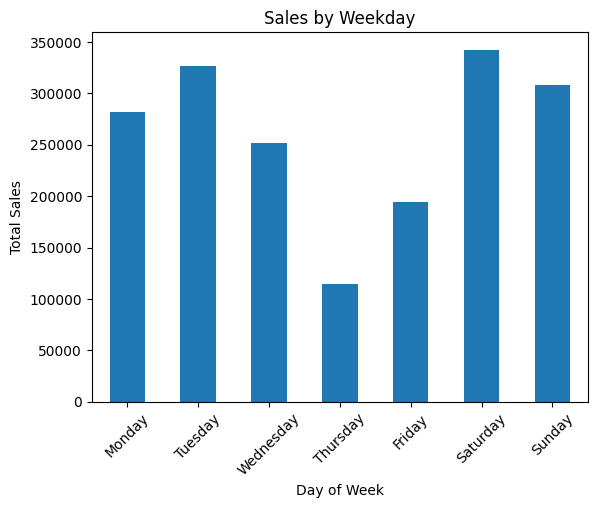

In [44]:
import matplotlib.pyplot as plt

sales_by_day.plot(kind='bar')

plt.title('Sales by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

Como vemos, los fines de semana son los días en los que más ventas se producen. Esto tiene sentido si pensamos en que son días en los que mucha gente no trabaja y, por lo tanto, tiene más tiempo disponible. Además, llama la atención las pocas ventas que se producen los días jueves. Podría recomendar la creación de alguna oferta especial u otro tipo de incentivo para que mejore la performance de la empresa los días jueves.

Ahora voy a hacer un análisis similar, pero con los meses del año. En este caso se podrán sacar otras conclusiones relacionadas con la estacionalidad del año, vacaciones, etc.

In [67]:
sales_by_month = df.groupby('Month')['Sales'].sum()

In [68]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

#sales_by_month = sales_by_month.reindex(month_order)

In [69]:
df["Sales"] = df["Sales"].astype(float)

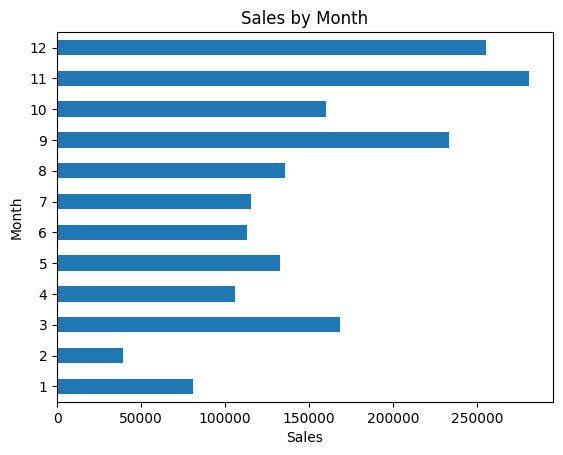

In [70]:
import matplotlib.pyplot as plt

sales_by_month.plot(kind='barh')

plt.title('Sales by Month')
plt.xlabel('Sales')
plt.ylabel('Month')

plt.show()

Vemos en el gráfico que el último cuatrimestre del año concentra más ventas totales que los dos primeros. Si tenemos en cuenta que durante esos meses ocurren eventos que modifican el comportamiento del consumo en los Estados Unidos, como el Black Friday y el Cyber Monday, durante el mes de noviembre, y la navidad durante el mes de diciembre. 

El mes de febrero se presenta como el de peor rendimiento. Es comprensible para una época donde ya pasó la temporada alta en la que los clientes compran y gastan más, y comienza otra en donde se cuidan los gastos.

Recomendaría diseñar estrategias para aumentar especialmente las ventas en los meses de octubre (ya que representa una oportunidad para anticipar campañas comerciales previas al pico de consumo de noviembre y diciembre) y febrero, donde ingresa menos dinero que en el resto de los meses y se necesita recuperar la demanda.

Si no se puede cambiar los hábitos de consumo de los clientes, se podría incentivar a vender productos más caros (tecnología, muebles) en dichos meses.

In [53]:
df.dtypes

Row ID                  int64
Order ID               object
Order Date             object
Ship Date              object
Ship Mode              object
Customer ID            object
Customer Name          object
Segment                object
Country                object
City                   object
State                  object
Postal Code           float64
Region                 object
Product ID             object
Category               object
Sub-Category           object
Product Name           object
Sales                 float64
Day Difference          int64
Year                    int64
Month                   int64
Month Name             object
Weekday                object
Customer Frequency      int64
Sales Category         object
dtype: object

In [56]:
df["Sales"] = df["Sales"].astype(float)

In [65]:
df['Sales'].dtype

dtype('float64')

A continuación, vamos a utilizar la columna creada de categorización de ventas (low, medium, high) para ver qué volumen de las ventas totales de cada categoría de productos representa cada clasificación:

In [71]:
category_sales = pd.crosstab(
    df['Category'],
    df['Sales Category']
)

print(category_sales)

Sales Category   High   Low  Medium
Category                           
Furniture         694   181     273
Office Supplies   774  2159    1576
Technology        983   113     600


In [72]:
category_sales_pct = pd.crosstab(
    df['Category'],
    df['Sales Category'],
    normalize='index'
) * 100

print(category_sales_pct)

Sales Category        High        Low     Medium
Category                                        
Furniture        60.452962  15.766551  23.780488
Office Supplies  17.165669  47.882014  34.952318
Technology       57.959906   6.662736  35.377358


En ambas tablas se ven los mismos datos pero mostrados de formas distintas: por cantidad y por porcentaje que representan del total. Para mejorar la performance en los meses/días indicados anteriormente es aconsejable priorizar las categorías de muebles y de tecnología, en las cuales un porcentaje mayoritario está asociado a tickets de un valor alto. Se pueden aplicar descuentos o pago en cuotas para aumentar el volumen de ventas en estas categorías.

Otra de las variables que se quiere analizar es la de tiempo de entrega. Vamos a ver una tabla que muestra la cantidad de días promedio de demora para la entrega de los productos. A su vez, se compararán los tiempos para cada una de las categorías, con el fin de profundizar más y sumar claridad.

In [76]:
avg_delivery = (
    df.groupby(['State', 'Category'])['Day Difference']
    .mean()
    .reset_index()
)

avg_delivery.columns = [
    'State',
    'Category',
    'Average Delivery Days'
]
pivot_delivery = avg_delivery.pivot(
    index='State',
    columns='Category',
    values='Average Delivery Days'
)

pivot_delivery

Category,Furniture,Office Supplies,Technology
State,,,
Alabama,4.250000,4.285714,4.214286
Arizona,3.969697,4.164948,3.913043
Arkansas,5.200000,3.758621,3.666667
California,3.919492,3.746120,4.011905
Colorado,3.354839,4.194030,3.558824
Connecticut,3.714286,3.434783,4.000000
Delaware,5.100000,4.414634,3.833333
District of Columbia,5.666667,5.750000,6.000000
Florida,3.895833,4.091429,4.000000


Una vez disponemos de los datos, vemos que en el distrito de Columbia la demora es mayor a los demás estados en las tres categorías. Se recomienda elaborar un plan para acercar los plazos de demora al promedio general.

Hay otros estados, como Nebraska, en los que la demora para los muebles es menor a los 2 días, pero para los productos tecnológicos es cercana a los 4 días. Se debería investigar por qué hay tal diferencia entre una categoría y otra. Puede ser un problema de tiempos del depósito, del transporte o del correo. Este planteo se extiende a varios estados y a las tres categorías.

Finalmente, se quiere saber qué subcategorías son las más rendidoras. Para ello vamos a ver qué volumen del total de ventas representa cada subcategoría, y luego las unidades vendidas de cada una. Primero vamos a ver subcategorías de tecnología: 

In [81]:
tech_sales = (
    df[df['Category'] == 'Technology']
    .groupby('Sub-Category')['Sales']
    .sum()
)

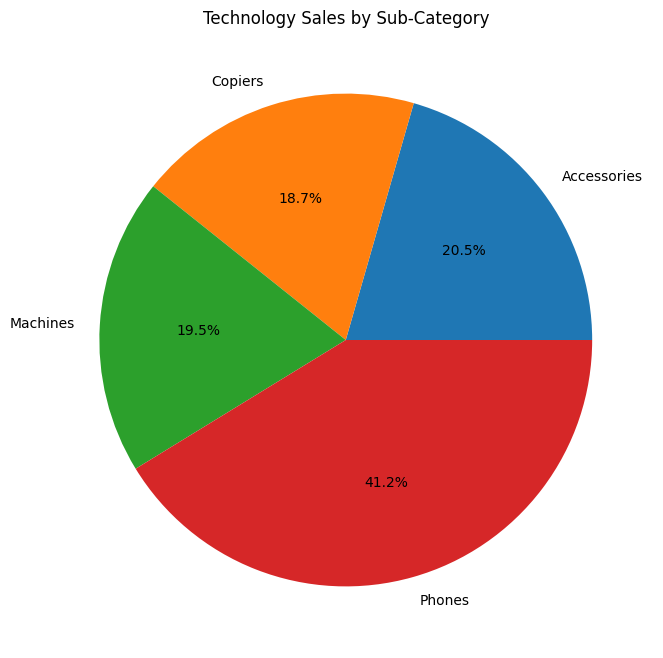

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

tech_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Technology Sales by Sub-Category')

plt.ylabel('')

plt.show()

In [83]:
tech_orders = (
    df[df['Category'] == 'Technology']
    .groupby('Sub-Category')
    .size()
)

print(tech_orders)

Sub-Category
Accessories    702
Copiers         66
Machines       101
Phones         827
dtype: int64


Vemos que los teléfonos representan el 41.2% de las ventas de tecnología, siendo además los productos tecnológicos que más se vendieron. Otra conclusión que se puede sacar es que las fotocopiadoras tienen el menor volumen de ventas y la menor cantidad de unidades vendidas. Sin embargo, la diferencia en volumen es muy corta con respecto a otras categorías como accesorios, donde las unidades vendidas son casi 10 veces más. Con lo cual, está a la vista que las fotocopiadoras se venden por precios altos y los accesorios por precios bastante menores.

Quizás se podría fomentar la venta de fotocopiadoras a segmentos de clientes que las utilizan más a menudo (empresas, negocios, etc) más que en clientes particulares. Eso requiere estrategias más elaboradas y de otras vías de comunicación y promoción.

Ahora vamos a hacer el mismo análisis para los productos de oficina.

In [84]:
os_sales = (
    df[df['Category'] == 'Office Supplies']
    .groupby('Sub-Category')['Sales']
    .sum()
)

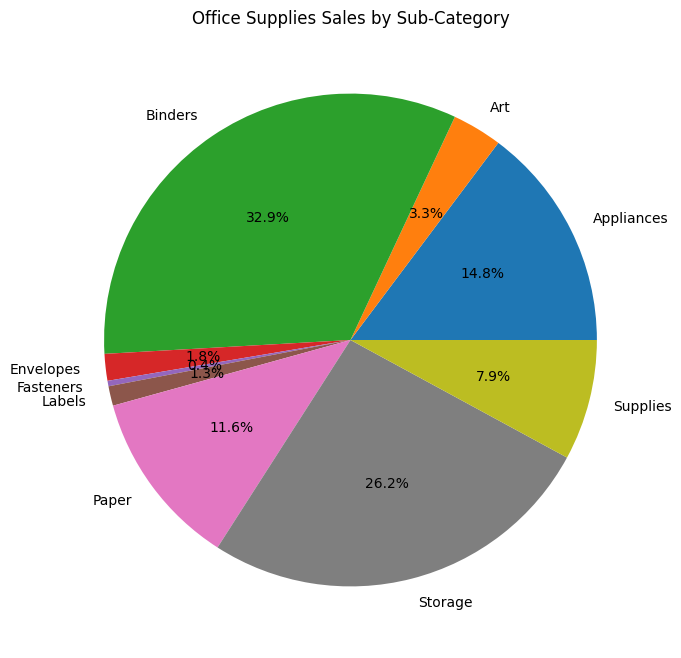

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

os_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Office Supplies Sales by Sub-Category')

plt.ylabel('')

plt.show()

In [86]:
os_orders = (
    df[df['Category'] == 'Office Supplies']
    .groupby('Sub-Category')
    .size()
)

print(os_orders)

Sub-Category
Appliances     360
Art            612
Binders       1128
Envelopes      157
Fasteners      166
Labels         323
Paper         1060
Storage        546
Supplies       157
dtype: int64


Las carpetas representan un tercio de las ventas de la categoría, siendo a su vez la subcategoría que más unidades vendidas posee. Con el papel pasa algo similar que con los accesorios tecnológicos. Al tener precios bajos, las unidades vendidas no impactan demasiado en el volumen de ventas. Lo mismo ocurre con el material artístico.

Finalmente, vamos a analizar las subcategorías de muebles:

In [87]:
fur_sales = (
    df[df['Category'] == 'Furniture']
    .groupby('Sub-Category')['Sales']
    .sum()
)

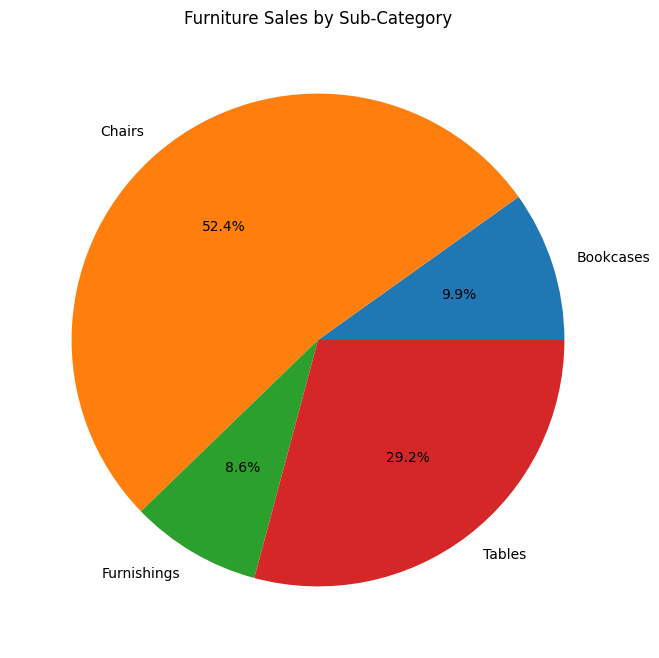

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

fur_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Furniture Sales by Sub-Category')

plt.ylabel('')

plt.show()

In [90]:
fur_orders = (
    df[df['Category'] == 'Furniture']
    .groupby('Sub-Category')
    .size()
)

print(fur_orders)

Sub-Category
Bookcases      101
Chairs         382
Furnishings    457
Tables         208
dtype: int64


En el caso de los muebles, vemos que las sillas son el producto "estrella" de la categoría. Representan más de la mitad del volumen de ventas y la cantidad de unidades vendidas está bastante por encima del promedio.

Los muebles y decoraciones (furnishings) son los productos más vendidos, y el impacto que tienen es mínimo. Con lo cual, recomiendo hacer énfasis en otros productos que rindan más.

Las mesas son un producto que ha tenido una buena performance: cantidad de unidades vendidas normal, incluso por debajo del promedio de la categoría, pero alto impacto en el volumen de ventas, representando casi un tercio del mismo.

Como conclusión, se recomienda profundizar la oferta y las estrategias de venta para las sillas y las mesas.